# 🛒 E-Commerce Sales Performance & Customer Behavior Analysis

- Tool: Python  
- Dataset: Brazilian E-Commerce 
- Author: Rakesh Sahoo
- Date: 1 may 2026  



## 📌 Project Objective
- Analyze sales performance across categories and states
- Understand customer behavior and payment patterns
- Identify delivery issues and their impact
- Provide actionable business recommendations

In [4]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import pandas as pd

orders = pd.read_csv('orders.csv')
customers = pd.read_csv('customers.csv')
order_items = pd.read_csv('order_items.csv')
products = pd.read_csv('products.csv')
payments = pd.read_csv('order_payments.csv')

In [ ]:
for name, df in zip(['orders','order_items','payments','customers','products'],
                   [orders,order_items,payments,customers,products]):
  print(name, df.shape)
  print(df.columns)

In [7]:
o=orders.drop_duplicates()
oi=order_items.drop_duplicates()
pm=payments.drop_duplicates()
cs=customers.drop_duplicates()
ps=products.drop_duplicates()

In [8]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])  #convert  date

ValueError: time data "24/07/2018 20:41" doesn't match format "%m/%d/%Y %H:%M", at position 1. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [9]:
orders=orders[orders['order_status'] == 'delivered']   #filter 

In [10]:
customers=customers.dropna(subset=['customer_id'])

In [11]:
order_items=order_items.dropna(subset=['price'])

In [12]:
order_items_ag = order_items.groupby('order_id')['price'].sum().reset_index()

In [13]:
payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.3
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.4
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.7
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.8
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.5
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.3
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.8
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.8
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.5


In [14]:
df.shape

(32951, 9)

In [15]:
for name, df in zip(['orders','order_items','payments','customers','products'],
                   [orders,order_items,payments,customers,products]):
  print(name, df.shape)
  print(df.columns)

orders (96478, 8)
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')
order_items (112650, 7)
Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')
payments (103886, 5)
Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', ' payment_value '],
      dtype='object')
customers (99441, 5)
Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')
products (32951, 9)
Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')


In [19]:
#order per customer
o_p_c = orders.groupby('customer_id')['order_id'].nunique()

repeat_customers = (o_p_c > 1).sum()
one_time_customer = (o_p_c == 1).sum()

print("Repeat_customers:",repeat_customers)
print("One_time_customer:",one_time_customer)

Repeat_customers: 0
One_time_customer: 96478


In [20]:
#order per customer
o_p_c = df1.groupby('customer_id')['order_id'].nunique()

repeat_customers = (o_p_c > 1).sum()
one_time_customer = (o_p_c == 1).sum()

print("Repeat_customers:",repeat_customers)
print("One_time_customer:",one_time_customer)

Repeat_customers: 0
One_time_customer: 96477


In [21]:
one_time_customer

np.int64(96477)

In [22]:
df1= orders.merge(order_items, on = 'order_id')\
        .merge(payments, on ='order_id')\
        .merge(customers, on ='customer_id')\
         .merge(products, on ='product_id')

In [23]:
df1

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02/10/2017 10:56,02/10/2017 11:07,04/10/2017 19:55,10/10/2017 21:25,18/10/2017 00:00,1,87285b34884572647811a353c7ac498a,...,sao paulo,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02/10/2017 10:56,02/10/2017 11:07,04/10/2017 19:55,10/10/2017 21:25,18/10/2017 00:00,1,87285b34884572647811a353c7ac498a,...,sao paulo,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02/10/2017 10:56,02/10/2017 11:07,04/10/2017 19:55,10/10/2017 21:25,18/10/2017 00:00,1,87285b34884572647811a353c7ac498a,...,sao paulo,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,24/07/2018 20:41,26/07/2018 03:24,26/07/2018 14:31,07/08/2018 15:27,13/08/2018 00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,barreiras,BA,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,08/08/2018 08:38,08/08/2018 08:55,08/08/2018 13:50,17/08/2018 18:06,04/09/2018 00:00,1,aa4383b373c6aca5d8797843e5594415,...,vianopolis,GO,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115030,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,06/02/2018 12:58,06/02/2018 13:10,07/02/2018 23:22,28/02/2018 17:37,02/03/2018 00:00,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,...,praia grande,SP,bebes,52.0,828.0,4.0,4950.0,40.0,10.0,40.0
115031,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,27/08/2017 14:46,27/08/2017 15:04,28/08/2017 20:52,21/09/2017 11:24,27/09/2017 00:00,1,b80910977a37536adeddd63663f916ad,...,nova vicosa,BA,eletrodomesticos_2,51.0,500.0,2.0,13300.0,32.0,90.0,22.0
115032,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,08/01/2018 21:28,08/01/2018 21:36,12/01/2018 15:35,25/01/2018 23:32,15/02/2018 00:00,1,d1c427060a0f73f6b889a5c7c61f2ac4,...,japuiba,RJ,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0
115033,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,08/01/2018 21:28,08/01/2018 21:36,12/01/2018 15:35,25/01/2018 23:32,15/02/2018 00:00,2,d1c427060a0f73f6b889a5c7c61f2ac4,...,japuiba,RJ,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0


In [24]:
# for removing space in all names

df1.columns = df1.columns.str.strip()

In [25]:
print('payment_value' in df1.columns)

True


In [26]:
#convert
df1['order_purchase_timestamp'] = pd.to_datetime(df1['order_purchase_timestamp'], dayfirst=True)

# Monthly revenue
                                                 
monthly_revenue = df1.groupby(df1['order_purchase_timestamp'].dt.to_period('M'))['payment_value'].sum()
print(monthly_revenue.head())

order_purchase_timestamp
2016-10     95.6  315.2  111.5  181.6  181.6  181.6  108....
2016-12                                                19.6 
2017-01     36.0  609.9  18.6  40.9  69.5  218.0  218.0  ...
2017-02     84.6  31.1  14.9  31.0  109.3  109.3  109.3  ...
2017-03     99.3  22.0  6.8  155.0  309.7  309.7  309.7  ...
Freq: M, Name: payment_value, dtype: object


In [27]:
df1.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

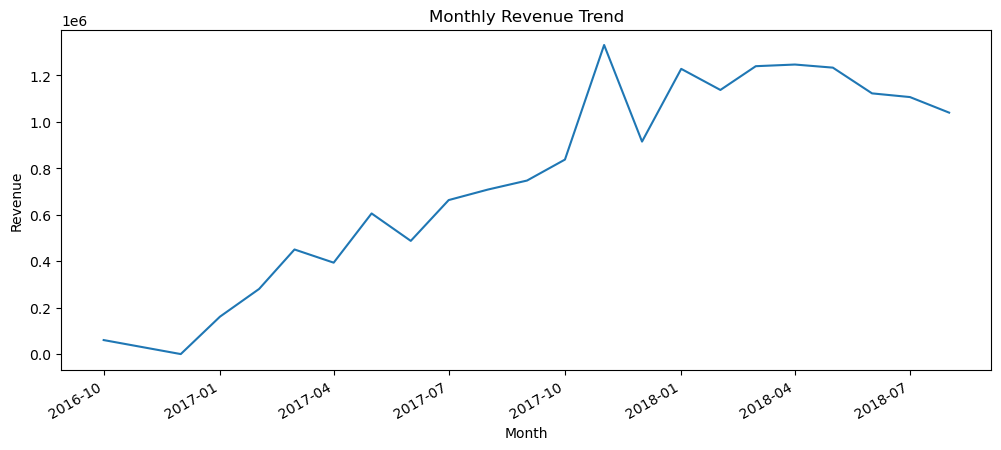

In [28]:
df1['payment_value'] = pd.to_numeric(df1['payment_value'], errors ='coerce')

monthly_revenue = df1.groupby(df1['order_purchase_timestamp'].dt.to_period('M'))['payment_value'].sum()

monthly_revenue.index = monthly_revenue.index.to_timestamp()

monthly_revenue.plot(figsize=(12,5))
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

**How many customers return to purchase again**

In [29]:
order_per_customer = (df1.groupby('customer_unique_id')['order_id'].nunique())

repeat_customers = (order_per_customer > 1).sum()
one_time_customer = (order_per_customer == 1).sum()

print("Repeat_customers:",repeat_customers)
print("One_time_customer:",one_time_customer)

Repeat_customers: 2801
One_time_customer: 90556


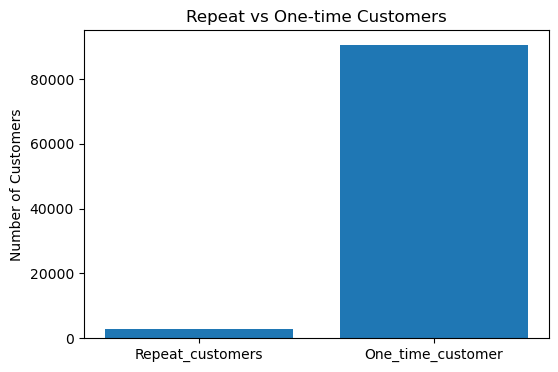

In [30]:
customer_counts = { "Repeat_customers":repeat_customers, "One_time_customer":one_time_customer}

plt.figure(figsize=(6,4))
plt.bar(customer_counts.keys(),customer_counts.values())
plt.title("Repeat vs One-time Customers")
plt.ylabel("Number of Customers")
plt.show()

**Customer lifetime Value**

In [31]:
clv = df1.groupby('customer_unique_id')['payment_value'].sum().reset_index().sort_values('payment_value',ascending = False)

clv.head(10)

,customer_unique_id,payment_value
6612,11f97da02237a49c8e783dfda6f50e8e,11745.0
79400,d97b3cfb22b0d6b25ac9ed4e9c2d481b,9774.4
49204,86df00dc5fd68f4dd5d5945ca19f3ed6,9602.0
87523,efce1ab3e96ccab8b1b464326bd22417,7971.5
10906,1da09dd64e235e7c2f29a4faff33535c,7708.8
44060,78b23d5ff07ebe2f082472ca242b9238,7551.0
90464,f7ea4eef770a388bd5b225acfc546604,7403.2
63183,ad0adff48be9c5f67cb35fd0895b42e7,7362.0
25676,4644f1b187e390a08b4c66fb16c91364,7316.4
11606,1f98d2384ff7a372e6a2d3bb75cbcd54,6906.9


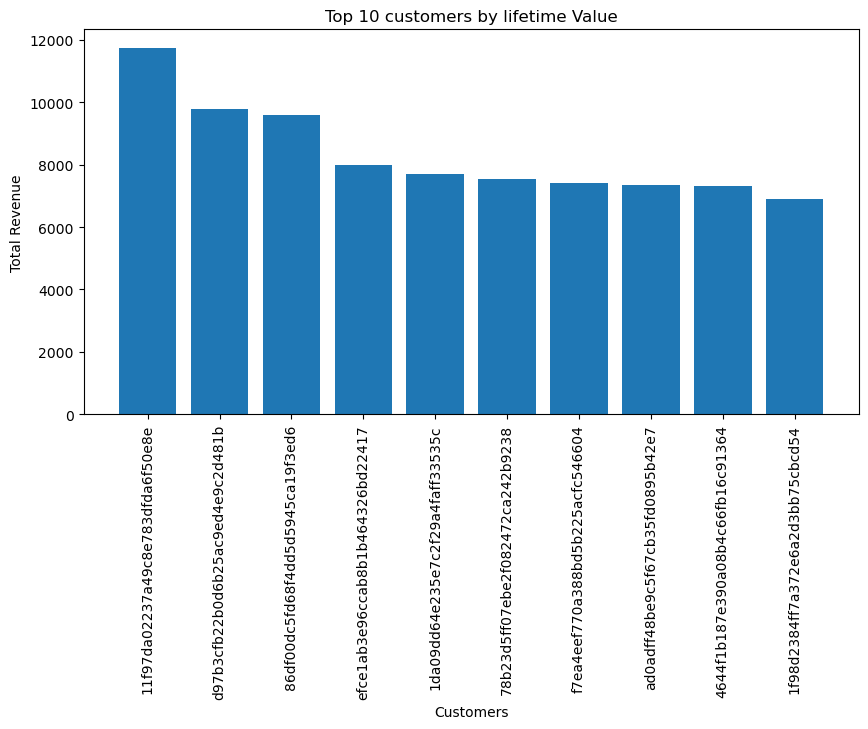

In [32]:
top_10_clv = clv.head(10)

plt.figure(figsize = (10,5))
plt.bar(top_10_clv['customer_unique_id'], top_10_clv['payment_value' ])
plt.title('Top 10 customers by lifetime Value')
plt.xlabel('Customers')
plt.ylabel('Total Revenue')
plt.xticks(rotation = 90)
plt.show()

In [33]:
# Revenue by payment method

payment_analysis = df1.groupby('payment_type')['payment_value'].sum().sort_values(ascending= False)
print(payment_analysis)

payment_type
credit_card    13121051.6
boleto          3264433.4
voucher          385813.0
debit_card       216028.2
Name: payment_value, dtype: float64


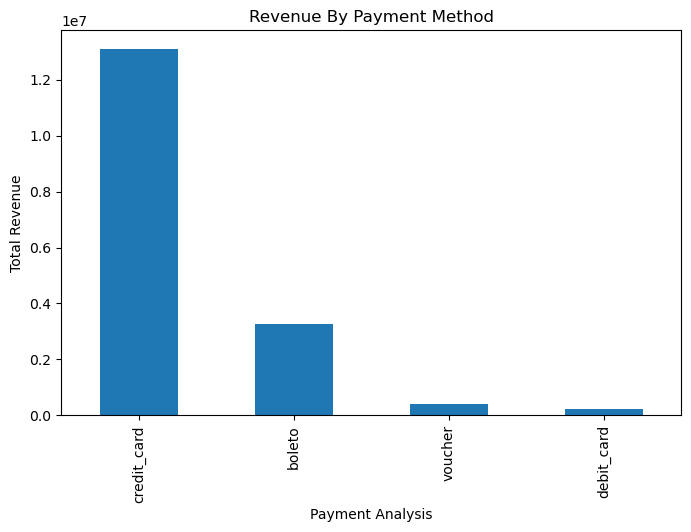

In [34]:
payment_analysis.plot(kind = 'bar' ,figsize=(8,5))
plt.title('Revenue By Payment Method')
plt.xlabel("Payment Analysis")
plt.ylabel("Total Revenue")
plt.xticks(rotation = 90)
plt.show()

**Which product category generated the best category**

In [35]:
df1['payment_value'] = pd.to_numeric(df1['payment_value'], errors='coerce')

In [36]:
df1.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

In [37]:
top_categories =(df1.groupby('product_category_name')['payment_value'].sum().sort_values(ascending= False))

top_categories.head(10)

product_category_name
cama_mesa_banho           1634049.2
beleza_saude              1441984.1
moveis_decoracao          1287876.0
informatica_acessorios    1258557.1
esporte_lazer             1229273.4
relogios_presentes        1199810.8
utilidades_domesticas      968316.0
cool_stuff                 699482.3
ferramentas_jardim         693095.8
automotivo                 655136.6
Name: payment_value, dtype: float64

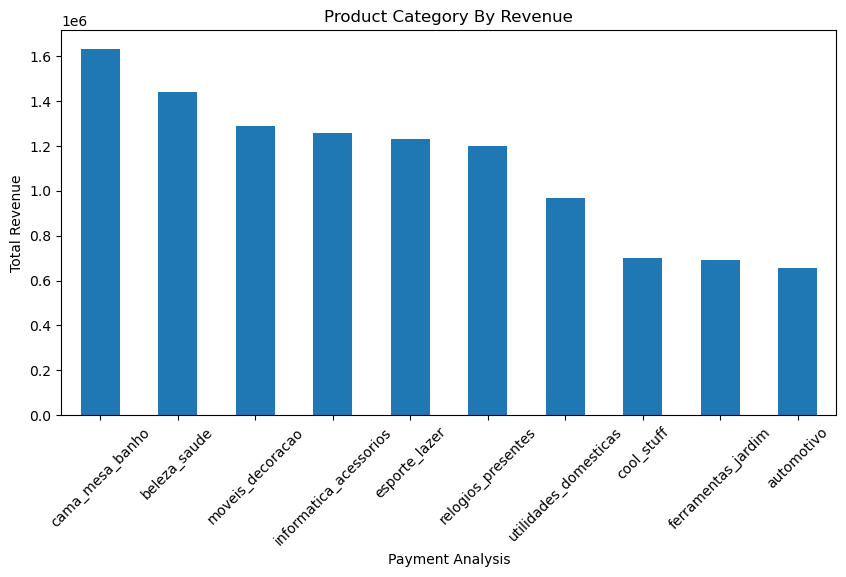

In [86]:
top_categories.head(10).plot( x= 'pdl', y='rev',kind = 'bar', figsize=(10,5))
plt.title('Product Category By Revenue')
plt.xlabel("Payment Analysis")
plt.ylabel("Total Revenue")
plt.xticks(rotation = 45)
plt.show()

In [91]:
df1.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [87]:
# date_columns = ['order_purchase_timestamp','order_approved_at',
#                 'order_delivered_carrier_date',
#                 'order_delivered_customer_date','order_estimated_delivery_date','shipping_limit_date']

# for col in date_columns:
#     if col in df1.columns:
#         df1[col] = pd.to_datetime(df1[col], errors= 'coerce')

In [104]:
df1['order_purchase_timestamp'] = pd.to_datetime(df1['order_purchase_timestamp'], format = "%d/%m/%Y %H:%M")

In [123]:
snapshot_date = df1['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = df1.groupby('customer_unique_id').agg(
         Recency=(
             'order_purchase_timestamp', 
             lambda x: (snapshot_date - x.max()).days
         ),
          Frequency=(
              'order_id',
              'nunique'
          ),
          Monetary=(
              'payment_value',
               'sum')
                ).reset_index()

In [129]:
rfm

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.9
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.2
2,0000f46a3911fa3c0805444483337064,537,1,86.2
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.6
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.9
...,...,...,...,...
93352,fffcf5a5ff07b0908bd4e2dbc735a684,447,1,0.0
93353,fffea47cd6d3cc0a88bd621562a9d061,262,1,84.6
93354,ffff371b4d645b6ecea244b27531430a,568,1,112.5
93355,ffff5962728ec6157033ef9805bacc48,119,1,133.7


In [130]:
rfm.columns

Index(['customer_unique_id', 'Recency', 'Frequency', 'Monetary'], dtype='object')

In [131]:
rfm.describe()

,Recency,Frequency,Monetary
count,93357.000000,93357.000000,93357.000000
mean,237.937155,1.033420,181.960926
std,152.584344,0.209099,279.727000
min,1.000000,1.000000,0.000000
25%,114.000000,1.000000,62.200000
50%,219.000000,1.000000,110.000000
75%,346.000000,1.000000,195.300000
max,695.000000,15.000000,11745.000000
